In [1]:
"""
# 01 · Model Evaluation for Scientific Imaging

En este notebook vamos a estudiar cómo evaluar modelos de clasificación aplicados a imágenes científicas.

En problemas reales de computer vision no alcanza con mirar solamente la accuracy global. Es necesario analizar:

- métricas por clase,
- matriz de confusión,
- precision, recall y F1-score,
- errores sistemáticos,
- confianza del modelo,
- ejemplos correctamente e incorrectamente clasificados.

Aunque usaremos el dataset "digits" de "scikit-learn" como ejemplo reproducible, la lógica es transferible a problemas de imágenes científicas como:

- clasificación de fases en microCT,
- detección de defectos,
- clasificación de texturas,
- análisis de materiales,
- imágenes de neutrones o rayos X.

## Objetivos del notebook

Al finalizar este notebook deberíamos poder:

- entrenar un modelo simple de clasificación,
- evaluar accuracy global,
- calcular métricas por clase,
- interpretar una matriz de confusión,
- analizar predicciones correctas e incorrectas,
- visualizar la confianza del modelo,
- discutir por qué la evaluación es crítica en scientific imaging.
"""

'\n# 01 · Model Evaluation for Scientific Imaging\n\nEn este notebook vamos a estudiar cómo evaluar modelos de clasificación aplicados a imágenes científicas.\n\nEn problemas reales de computer vision no alcanza con mirar solamente la accuracy global. Es necesario analizar:\n\n- métricas por clase,\n- matriz de confusión,\n- precision, recall y F1-score,\n- errores sistemáticos,\n- confianza del modelo,\n- ejemplos correctamente e incorrectamente clasificados.\n\nAunque usaremos el dataset "digits" de "scikit-learn" como ejemplo reproducible, la lógica es transferible a problemas de imágenes científicas como:\n\n- clasificación de fases en microCT,\n- detección de defectos,\n- clasificación de texturas,\n- análisis de materiales,\n- imágenes de neutrones o rayos X.\n\n## Objetivos del notebook\n\nAl finalizar este notebook deberíamos poder:\n\n- entrenar un modelo simple de clasificación,\n- evaluar accuracy global,\n- calcular métricas por clase,\n- interpretar una matriz de confusión

In [2]:
# ------------------------------------------------------------
# 01 · Imports and general configuration
# ------------------------------------------------------------

from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_recall_fscore_support
)

from torch.utils.data import TensorDataset, DataLoader

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Project paths
NOTEBOOK_DIR = Path.cwd()
PROJECT_DIR = NOTEBOOK_DIR.parent

FIGURES_DIR = PROJECT_DIR / "figures"
MODELS_DIR = PROJECT_DIR / "models"
RESULTS_DIR = PROJECT_DIR / "results"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Selected device: {device}")
print(f"Figures directory: {FIGURES_DIR}")
print(f"Results directory: {RESULTS_DIR}")

PyTorch version: 2.10.0+cpu
Selected device: cpu
Figures directory: C:\Users\Peter\ai-imaging-portfolio\06_explainability_and_evaluation\figures
Results directory: C:\Users\Peter\ai-imaging-portfolio\06_explainability_and_evaluation\results


In [3]:
"""
## 1. Carga del dataset

Vamos a usar el dataset "digits" de "scikit-learn".

Cada muestra es una imagen pequeña de 8×8 píxeles correspondiente a un dígito manuscrito entre 0 y 9.

En este notebook lo usamos como un caso controlado para estudiar evaluación de modelos. En un proyecto científico real, 
cada clase podría representar una fase, una textura, un defecto, una litología o una categoría experimental.
"""

'\n## 1. Carga del dataset\n\nVamos a usar el dataset "digits" de "scikit-learn".\n\nCada muestra es una imagen pequeña de 8×8 píxeles correspondiente a un dígito manuscrito entre 0 y 9.\n\nEn este notebook lo usamos como un caso controlado para estudiar evaluación de modelos. En un proyecto científico real, \ncada clase podría representar una fase, una textura, un defecto, una litología o una categoría experimental.\n'

In [4]:
# ------------------------------------------------------------
# 02 · Load dataset
# ------------------------------------------------------------

digits = load_digits()

X = digits.data.astype(np.float32)
y = digits.target.astype(np.int64)

class_names = [str(c) for c in digits.target_names]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Number of classes:", len(class_names))
print("Classes:", class_names)

X shape: (1797, 64)
y shape: (1797,)
Number of classes: 10
Classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


In [5]:
# ------------------------------------------------------------
# 03 · Normalize input data
# ------------------------------------------------------------

# The digits dataset has pixel values approximately in the range [0, 16].
# We normalize them to [0, 1] for neural network training.
X = X / 16.0

print("Min value:", X.min())
print("Max value:", X.max())

Min value: 0.0
Max value: 1.0


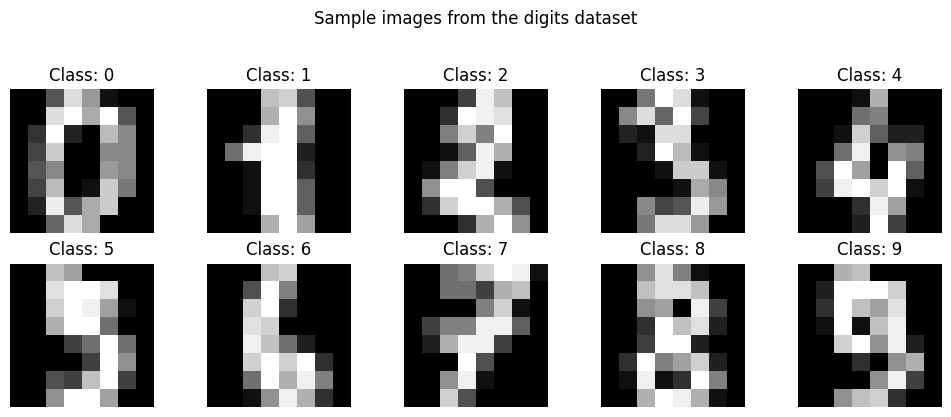

Figure saved to: C:\Users\Peter\ai-imaging-portfolio\06_explainability_and_evaluation\figures\01_digits_sample_images.png


In [6]:
# ------------------------------------------------------------
# 04 · Visualize sample images
# ------------------------------------------------------------

fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i, ax in enumerate(axes.flat):
    ax.imshow(X[i].reshape(8, 8), cmap="gray")
    ax.set_title(f"Class: {y[i]}")
    ax.axis("off")

plt.suptitle("Sample images from the digits dataset", y=1.03)
plt.tight_layout()

out = FIGURES_DIR / "01_digits_sample_images.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {out}")

In [7]:
"""
## 2. División en train, validation y test

Para evaluar correctamente un modelo separamos los datos en tres conjuntos:

- "Train:" se usa para ajustar los pesos del modelo.
- "Validation:" se usa para monitorear el entrenamiento y tomar decisiones.
- "Test:" se usa solo al final para estimar la generalización.

Esta separación es especialmente importante en imágenes científicas, donde podemos tener pocos datos y riesgo de sobreajuste.
"""

'\n## 2. División en train, validation y test\n\nPara evaluar correctamente un modelo separamos los datos en tres conjuntos:\n\n- "Train:" se usa para ajustar los pesos del modelo.\n- "Validation:" se usa para monitorear el entrenamiento y tomar decisiones.\n- "Test:" se usa solo al final para estimar la generalización.\n\nEsta separación es especialmente importante en imágenes científicas, donde podemos tener pocos datos y riesgo de sobreajuste.\n'

In [8]:
# ------------------------------------------------------------
# 05 · Train / validation / test split
# ------------------------------------------------------------

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=SEED,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

print("Train:", X_train.shape, y_train.shape)
print("Val  :", X_val.shape, y_val.shape)
print("Test :", X_test.shape, y_test.shape)

Train: (1257, 64) (1257,)
Val  : (270, 64) (270,)
Test : (270, 64) (270,)


In [14]:
# ------------------------------------------------------------
# 06 · Create DataLoaders
# ------------------------------------------------------------

batch_size = 32

X_train_t = torch.from_numpy(X_train)
X_val_t   = torch.from_numpy(X_val)
X_test_t  = torch.from_numpy(X_test)

y_train_t = torch.from_numpy(y_train)
y_val_t   = torch.from_numpy(y_val)
y_test_t  = torch.from_numpy(y_test)

train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset   = TensorDataset(X_val_t, y_val_t)
test_dataset  = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Train batches:", len(train_loader))
print("Val batches  :", len(val_loader))
print("Test batches :", len(test_loader))

Train batches: 40
Val batches  : 9
Test batches : 9


In [15]:
"""
## 3. Modelo base para evaluación

Para estudiar métricas y errores necesitamos primero un modelo entrenado.

Usaremos un MLP simple:

"text
64 → 128 → 64 → 10
"""

'\n## 3. Modelo base para evaluación\n\nPara estudiar métricas y errores necesitamos primero un modelo entrenado.\n\nUsaremos un MLP simple:\n\n"text\n64 → 128 → 64 → 10\n'

In [16]:

## Celda 11 — Código

#python
# ------------------------------------------------------------
# 07 · Define baseline MLP model
# ------------------------------------------------------------

class MLPClassifier(nn.Module):
    def __init__(self, input_dim=64, hidden_dim=128, output_dim=10):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, output_dim)
        )

    def forward(self, x):
        return self.network(x)


model = MLPClassifier().to(device)

print(model)

MLPClassifier(
  (network): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [17]:
# ------------------------------------------------------------
# 08 · Loss function and optimizer
# ------------------------------------------------------------

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("Loss function:", criterion)
print("Optimizer:", optimizer)

Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [18]:
"""
## 4. Funciones de entrenamiento y evaluación

Separar el entrenamiento y la evaluación en funciones hace que el notebook sea más claro y reutilizable.

Usaremos:

- "train_one_epoch()" para entrenar una época.
- "evaluate()" para calcular loss, accuracy, etiquetas reales, predicciones y probabilidades.
"""

'\n## 4. Funciones de entrenamiento y evaluación\n\nSeparar el entrenamiento y la evaluación en funciones hace que el notebook sea más claro y reutilizable.\n\nUsaremos:\n\n- "train_one_epoch()" para entrenar una época.\n- "evaluate()" para calcular loss, accuracy, etiquetas reales, predicciones y probabilidades.\n'

In [19]:
# ------------------------------------------------------------
# 09 · Train one epoch
# ------------------------------------------------------------

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for X_batch, y_batch in dataloader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        logits = model(X_batch)
        loss = criterion(logits, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

        predictions = torch.argmax(logits, dim=1)
        correct += (predictions == y_batch).sum().item()
        total += y_batch.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [20]:
# ------------------------------------------------------------
# 10 · Evaluate model
# ------------------------------------------------------------

def evaluate(model, dataloader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            probs = torch.softmax(logits, dim=1)
            predictions = torch.argmax(probs, dim=1)

            running_loss += loss.item() * X_batch.size(0)

            correct += (predictions == y_batch).sum().item()
            total += y_batch.size(0)

            all_labels.extend(y_batch.cpu().numpy())
            all_preds.extend(predictions.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return {
        "loss": epoch_loss,
        "accuracy": epoch_acc,
        "labels": np.array(all_labels),
        "predictions": np.array(all_preds),
        "probabilities": np.array(all_probs)
    }

In [22]:
"""
## 5. Entrenamiento del modelo base

Entrenaremos el modelo durante pocas epoch.

No buscamos optimizar al máximo la arquitectura, sino obtener un clasificador razonable para estudiar métricas de evaluación.
"""

'\n## 5. Entrenamiento del modelo base\n\nEntrenaremos el modelo durante pocas epoch.\n\nNo buscamos optimizar al máximo la arquitectura, sino obtener un clasificador razonable para estudiar métricas de evaluación.\n'

In [23]:
# ------------------------------------------------------------
# 11 · Train baseline model
# ------------------------------------------------------------

n_epochs = 50

history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

for epoch in range(n_epochs):
    train_loss, train_acc = train_one_epoch(
        model=model,
        dataloader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device
    )

    val_metrics = evaluate(
        model=model,
        dataloader=val_loader,
        criterion=criterion,
        device=device
    )

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_acc)
    history["val_loss"].append(val_metrics["loss"])
    history["val_accuracy"].append(val_metrics["accuracy"])

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch [{epoch+1:03d}/{n_epochs}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_metrics['loss']:.4f} | "
            f"Val Acc: {val_metrics['accuracy']:.4f}"
        )

Epoch [010/50] | Train Loss: 0.1309 | Train Acc: 0.9714 | Val Loss: 0.1733 | Val Acc: 0.9519
Epoch [020/50] | Train Loss: 0.0543 | Train Acc: 0.9881 | Val Loss: 0.1356 | Val Acc: 0.9667
Epoch [030/50] | Train Loss: 0.0262 | Train Acc: 0.9968 | Val Loss: 0.1196 | Val Acc: 0.9741
Epoch [040/50] | Train Loss: 0.0125 | Train Acc: 1.0000 | Val Loss: 0.1192 | Val Acc: 0.9667
Epoch [050/50] | Train Loss: 0.0064 | Train Acc: 1.0000 | Val Loss: 0.1249 | Val Acc: 0.9704


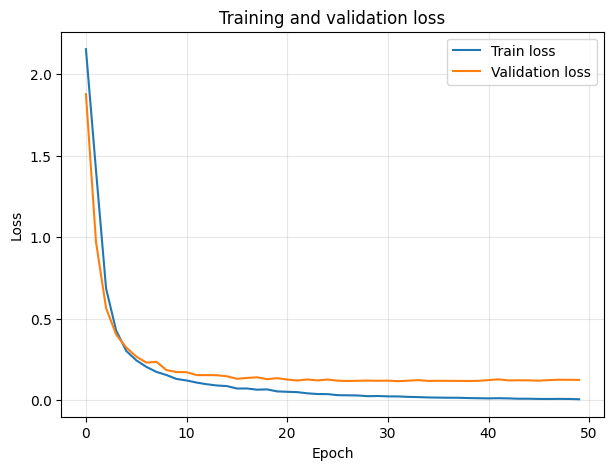

Figure saved to: C:\Users\Peter\ai-imaging-portfolio\06_explainability_and_evaluation\figures\01_training_validation_loss.png


In [24]:
# ------------------------------------------------------------
# 12 · Plot training and validation loss
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

plt.plot(history["train_loss"], label="Train loss")
plt.plot(history["val_loss"], label="Validation loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and validation loss")
plt.legend()
plt.grid(alpha=0.3)

out = FIGURES_DIR / "01_training_validation_loss.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {out}")

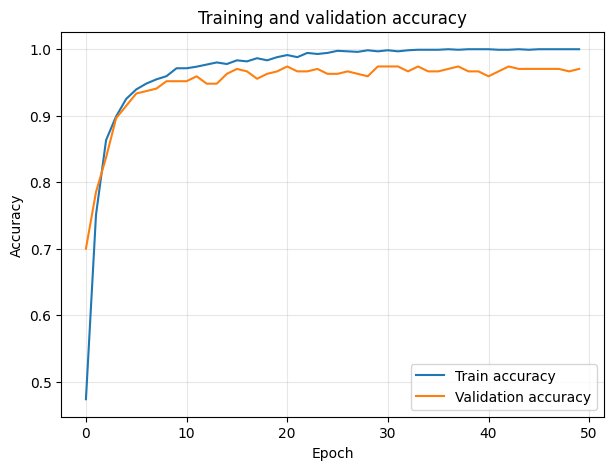

Figure saved to: C:\Users\Peter\ai-imaging-portfolio\06_explainability_and_evaluation\figures\01_training_validation_accuracy.png


In [25]:
# ------------------------------------------------------------
# 13 · Plot training and validation accuracy
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

plt.plot(history["train_accuracy"], label="Train accuracy")
plt.plot(history["val_accuracy"], label="Validation accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.grid(alpha=0.3)

out = FIGURES_DIR / "01_training_validation_accuracy.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {out}")

In [26]:
"""
## 6. Primera interpretación del entrenamiento

El modelo alcanza accuracy muy alta en entrenamiento y validación.

Sin embargo, se observa que la accuracy de entrenamiento llega a 1.0 mientras la accuracy de validación queda algo más baja.

Esto puede indicar un leve sobreajuste, aunque el modelo todavía generaliza bien.

En scientific imaging, este análisis es importante porque datasets pequeños pueden producir métricas aparentemente buenas, 
pero con errores concentrados en clases específicas o en condiciones experimentales particulares.
"""

'\n## 6. Primera interpretación del entrenamiento\n\nEl modelo alcanza accuracy muy alta en entrenamiento y validación.\n\nSin embargo, se observa que la accuracy de entrenamiento llega a 1.0 mientras la accuracy de validación queda algo más baja.\n\nEsto puede indicar un leve sobreajuste, aunque el modelo todavía generaliza bien.\n\nEn scientific imaging, este análisis es importante porque datasets pequeños pueden producir métricas aparentemente buenas, \npero con errores concentrados en clases específicas o en condiciones experimentales particulares.\n'

In [27]:
# ------------------------------------------------------------
# 14 · Final evaluation on test set
# ------------------------------------------------------------

test_metrics = evaluate(
    model=model,
    dataloader=test_loader,
    criterion=criterion,
    device=device
)

print(f"Test loss     : {test_metrics['loss']:.4f}")
print(f"Test accuracy : {test_metrics['accuracy']:.4f}")

Test loss     : 0.0819
Test accuracy : 0.9778


In [28]:
"""
## 7. Accuracy global

La accuracy global mide la fracción de muestras correctamente clasificadas:

\[
Accuracy = \frac{\text{predicciones correctas}}{\text{total de muestras}}
\]

Es una métrica útil, pero puede ser insuficiente.

Por ejemplo, en un problema científico con clases desbalanceadas, un modelo puede tener accuracy alta y aun así fallar en la clase más importante.
"""

'\n## 7. Accuracy global\n\nLa accuracy global mide la fracción de muestras correctamente clasificadas:\n\n\\[\nAccuracy = \x0crac{\text{predicciones correctas}}{\text{total de muestras}}\n\\]\n\nEs una métrica útil, pero puede ser insuficiente.\n\nPor ejemplo, en un problema científico con clases desbalanceadas, un modelo puede tener accuracy alta y aun así fallar en la clase más importante.\n'

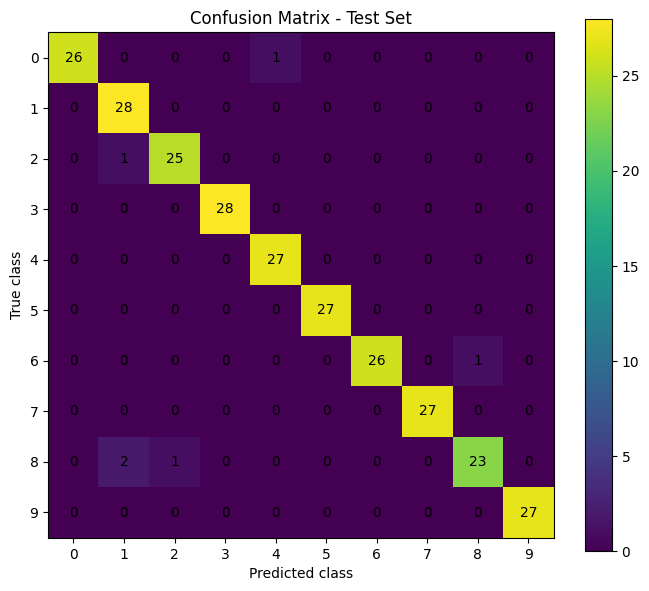

Figure saved to: C:\Users\Peter\ai-imaging-portfolio\06_explainability_and_evaluation\figures\01_confusion_matrix_test.png


In [29]:
# ------------------------------------------------------------
# 15 · Confusion matrix
# ------------------------------------------------------------

y_true = test_metrics["labels"]
y_pred = test_metrics["predictions"]

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
plt.imshow(cm)

plt.title("Confusion Matrix - Test Set")
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.colorbar()

plt.xticks(np.arange(len(class_names)), class_names)
plt.yticks(np.arange(len(class_names)), class_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()

out = FIGURES_DIR / "01_confusion_matrix_test.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {out}")

In [30]:
"""
## 8. Matriz de confusión

La matriz de confusión permite ver qué clases se confunden entre sí.

Cada fila representa la clase verdadera y cada columna representa la clase predicha.

La diagonal principal contiene las predicciones correctas.

Los valores fuera de la diagonal indican errores.

En imágenes científicas, esta matriz es muy útil para detectar problemas como:

- fases que el modelo confunde,
- defectos visualmente similares,
- clases con bajo contraste,
- categorías con pocas muestras,
- sesgos del dataset.
"""

'\n## 8. Matriz de confusión\n\nLa matriz de confusión permite ver qué clases se confunden entre sí.\n\nCada fila representa la clase verdadera y cada columna representa la clase predicha.\n\nLa diagonal principal contiene las predicciones correctas.\n\nLos valores fuera de la diagonal indican errores.\n\nEn imágenes científicas, esta matriz es muy útil para detectar problemas como:\n\n- fases que el modelo confunde,\n- defectos visualmente similares,\n- clases con bajo contraste,\n- categorías con pocas muestras,\n- sesgos del dataset.\n'

In [31]:
# ------------------------------------------------------------
# 16 · Classification report
# ------------------------------------------------------------

report_text = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

print(report_text)

              precision    recall  f1-score   support

           0       1.00      0.96      0.98        27
           1       0.90      1.00      0.95        28
           2       0.96      0.96      0.96        26
           3       1.00      1.00      1.00        28
           4       0.96      1.00      0.98        27
           5       1.00      1.00      1.00        27
           6       1.00      0.96      0.98        27
           7       1.00      1.00      1.00        27
           8       0.96      0.88      0.92        26
           9       1.00      1.00      1.00        27

    accuracy                           0.98       270
   macro avg       0.98      0.98      0.98       270
weighted avg       0.98      0.98      0.98       270



In [32]:
# ------------------------------------------------------------
# 17 · Per-class metrics as DataFrame
# ------------------------------------------------------------

precision, recall, f1, support = precision_recall_fscore_support(
    y_true,
    y_pred,
    labels=np.arange(len(class_names)),
    zero_division=0
)

metrics_df = pd.DataFrame({
    "class": class_names,
    "precision": precision,
    "recall": recall,
    "f1_score": f1,
    "support": support
})

metrics_df

,class,precision,recall,f1_score,support
0,0,1.000000,0.962963,0.981132,27
1,1,0.903226,1.000000,0.949153,28
2,2,0.961538,0.961538,0.961538,26
3,3,1.000000,1.000000,1.000000,28
4,4,0.964286,1.000000,0.981818,27
5,5,1.000000,1.000000,1.000000,27
6,6,1.000000,0.962963,0.981132,27
7,7,1.000000,1.000000,1.000000,27
8,8,0.958333,0.884615,0.920000,26
9,9,1.000000,1.000000,1.000000,27


In [33]:
# ------------------------------------------------------------
# 18 · Save per-class metrics
# ------------------------------------------------------------

metrics_path = RESULTS_DIR / "01_per_class_metrics.csv"

metrics_df.to_csv(metrics_path, index=False)

print(f"Metrics saved to: {metrics_path}")

Metrics saved to: C:\Users\Peter\ai-imaging-portfolio\06_explainability_and_evaluation\results\01_per_class_metrics.csv


In [34]:
"""
## 9. Precision, recall y F1-score

La accuracy global resume el rendimiento en un solo número, pero no muestra el comportamiento clase por clase.

Por eso usamos métricas adicionales:

### Precision

Indica cuántas de las muestras predichas como una clase realmente pertenecen a esa clase.

### Recall

Indica cuántas de las muestras reales de una clase fueron correctamente detectadas.

### F1-score

Combina precision y recall en una sola métrica.

En scientific imaging, el recall puede ser especialmente importante cuando no queremos perder casos críticos, 
por ejemplo defectos, grietas, fases minoritarias o regiones de interés pequeñas.
"""

'\n## 9. Precision, recall y F1-score\n\nLa accuracy global resume el rendimiento en un solo número, pero no muestra el comportamiento clase por clase.\n\nPor eso usamos métricas adicionales:\n\n### Precision\n\nIndica cuántas de las muestras predichas como una clase realmente pertenecen a esa clase.\n\n### Recall\n\nIndica cuántas de las muestras reales de una clase fueron correctamente detectadas.\n\n### F1-score\n\nCombina precision y recall en una sola métrica.\n\nEn scientific imaging, el recall puede ser especialmente importante cuando no queremos perder casos críticos, \npor ejemplo defectos, grietas, fases minoritarias o regiones de interés pequeñas.\n'

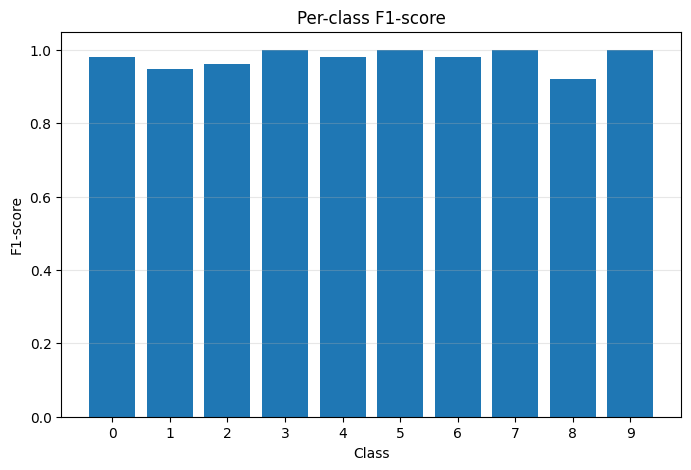

Figure saved to: C:\Users\Peter\ai-imaging-portfolio\06_explainability_and_evaluation\figures\01_per_class_f1_score.png


In [35]:
# ------------------------------------------------------------
# 19 · Plot per-class F1-score
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.bar(metrics_df["class"], metrics_df["f1_score"])

plt.xlabel("Class")
plt.ylabel("F1-score")
plt.title("Per-class F1-score")
plt.ylim(0, 1.05)
plt.grid(axis="y", alpha=0.3)

out = FIGURES_DIR / "01_per_class_f1_score.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {out}")

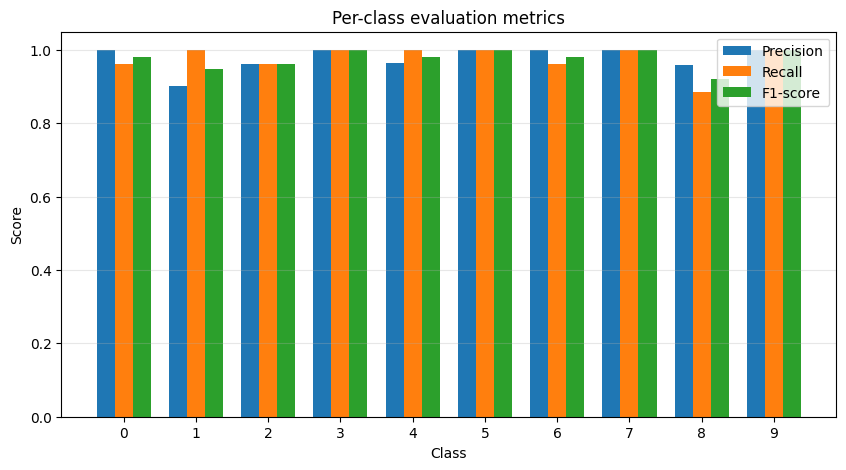

Figure saved to: C:\Users\Peter\ai-imaging-portfolio\06_explainability_and_evaluation\figures\01_per_class_precision_recall_f1.png


In [36]:
# ------------------------------------------------------------
# 20 · Plot precision, recall and F1-score per class
# ------------------------------------------------------------

x_pos = np.arange(len(metrics_df))
width = 0.25

plt.figure(figsize=(10, 5))

plt.bar(x_pos - width, metrics_df["precision"], width=width, label="Precision")
plt.bar(x_pos, metrics_df["recall"], width=width, label="Recall")
plt.bar(x_pos + width, metrics_df["f1_score"], width=width, label="F1-score")

plt.xticks(x_pos, metrics_df["class"])
plt.xlabel("Class")
plt.ylabel("Score")
plt.title("Per-class evaluation metrics")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(axis="y", alpha=0.3)

out = FIGURES_DIR / "01_per_class_precision_recall_f1.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {out}")

In [37]:
"""
## 10. Lectura de las métricas por clase

Las métricas por clase muestran que el modelo no se comporta igual para todas las categorías.

En este caso, la clase "8" presenta el F1-score más bajo. Esto indica que es una clase relativamente más difícil para el modelo.

La clase "1" presenta menor precision, lo que sugiere que algunas muestras de otras clases fueron predichas incorrectamente como "1".

En problemas de scientific imaging, este tipo de análisis es fundamental. Una accuracy global alta puede ocultar errores importantes en 
clases minoritarias, fases críticas o estructuras visualmente similares.
"""

'\n## 10. Lectura de las métricas por clase\n\nLas métricas por clase muestran que el modelo no se comporta igual para todas las categorías.\n\nEn este caso, la clase "8" presenta el F1-score más bajo. Esto indica que es una clase relativamente más difícil para el modelo.\n\nLa clase "1" presenta menor precision, lo que sugiere que algunas muestras de otras clases fueron predichas incorrectamente como "1".\n\nEn problemas de scientific imaging, este tipo de análisis es fundamental. Una accuracy global alta puede ocultar errores importantes en \nclases minoritarias, fases críticas o estructuras visualmente similares.\n'

In [38]:
# ------------------------------------------------------------
# 21 · Prediction confidence
# ------------------------------------------------------------

probs = test_metrics["probabilities"]

confidence = probs.max(axis=1)
predicted_class = probs.argmax(axis=1)

evaluation_df = pd.DataFrame({
    "true_label": y_true,
    "predicted_label": y_pred,
    "confidence": confidence,
    "correct": y_true == y_pred
})

evaluation_df.head()

,true_label,predicted_label,confidence,correct
0,6,6,0.999822,True
1,1,1,0.999840,True
2,8,8,0.993810,True
3,1,1,0.999761,True
4,3,3,0.999945,True


In [39]:
# ------------------------------------------------------------
# 22 · Confidence summary
# ------------------------------------------------------------

confidence_summary = evaluation_df.groupby("correct")["confidence"].describe()

confidence_summary

,count,mean,std,min,25%,50%,75%,max
correct,,,,,,,,
False,6.0,0.876635,0.061272,0.825797,0.840919,0.866322,0.871861,0.995208
True,264.0,0.982839,0.064552,0.460898,0.998455,0.999908,0.999992,1.000000


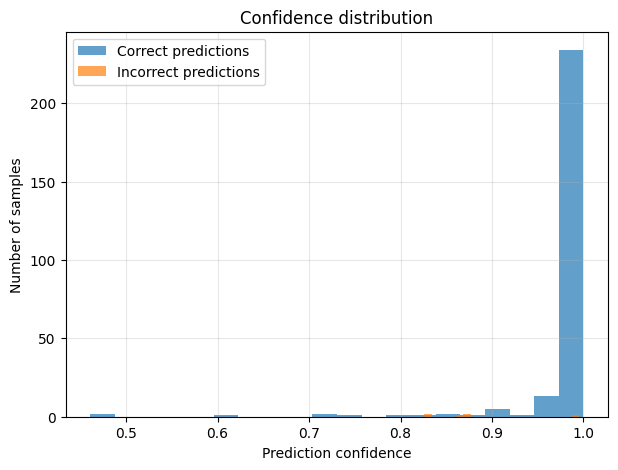

Figure saved to: C:\Users\Peter\ai-imaging-portfolio\06_explainability_and_evaluation\figures\01_confidence_distribution.png


In [40]:
# ------------------------------------------------------------
# 23 · Plot confidence distribution
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

plt.hist(
    evaluation_df.loc[evaluation_df["correct"], "confidence"],
    bins=20,
    alpha=0.7,
    label="Correct predictions"
)

plt.hist(
    evaluation_df.loc[~evaluation_df["correct"], "confidence"],
    bins=20,
    alpha=0.7,
    label="Incorrect predictions"
)

plt.xlabel("Prediction confidence")
plt.ylabel("Number of samples")
plt.title("Confidence distribution")
plt.legend()
plt.grid(alpha=0.3)

out = FIGURES_DIR / "01_confidence_distribution.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {out}")

In [41]:
# ------------------------------------------------------------
# 24 · Incorrect predictions
# ------------------------------------------------------------

errors_df = evaluation_df[~evaluation_df["correct"]].copy()

errors_df = errors_df.sort_values("confidence", ascending=False)

print("Number of errors:", len(errors_df))
errors_df.head(10)

Number of errors: 6


,true_label,predicted_label,confidence,correct
121,8,1,0.995208,False
107,8,2,0.873038,False
168,6,8,0.868330,False
36,2,1,0.864314,False
218,0,4,0.833121,False
96,8,1,0.825797,False


In [42]:
# ------------------------------------------------------------
# 25 · Save prediction-level evaluation table
# ------------------------------------------------------------

evaluation_path = RESULTS_DIR / "01_prediction_level_evaluation.csv"

evaluation_df.to_csv(evaluation_path, index=False)

print(f"Prediction-level evaluation saved to: {evaluation_path}")

Prediction-level evaluation saved to: C:\Users\Peter\ai-imaging-portfolio\06_explainability_and_evaluation\results\01_prediction_level_evaluation.csv


In [43]:
"""
## 11. Análisis de errores

El análisis de errores permite estudiar no solo cuántas veces se equivoca el modelo, sino también cómo se equivoca.

Algunas preguntas importantes son:

- ¿Qué clases se confunden con más frecuencia?
- ¿El modelo se equivoca con baja o alta confianza?
- ¿Los errores aparecen en imágenes ambiguas?
- ¿Hay patrones visuales asociados a los errores?
- ¿Hay clases sistemáticamente más difíciles?

En scientific imaging, este paso puede revelar problemas del dataset, errores de etiquetado, bajo contraste, artefactos de 
adquisición o límites reales del modelo.
"""

'\n## 11. Análisis de errores\n\nEl análisis de errores permite estudiar no solo cuántas veces se equivoca el modelo, sino también cómo se equivoca.\n\nAlgunas preguntas importantes son:\n\n- ¿Qué clases se confunden con más frecuencia?\n- ¿El modelo se equivoca con baja o alta confianza?\n- ¿Los errores aparecen en imágenes ambiguas?\n- ¿Hay patrones visuales asociados a los errores?\n- ¿Hay clases sistemáticamente más difíciles?\n\nEn scientific imaging, este paso puede revelar problemas del dataset, errores de etiquetado, bajo contraste, artefactos de \nadquisición o límites reales del modelo.\n'

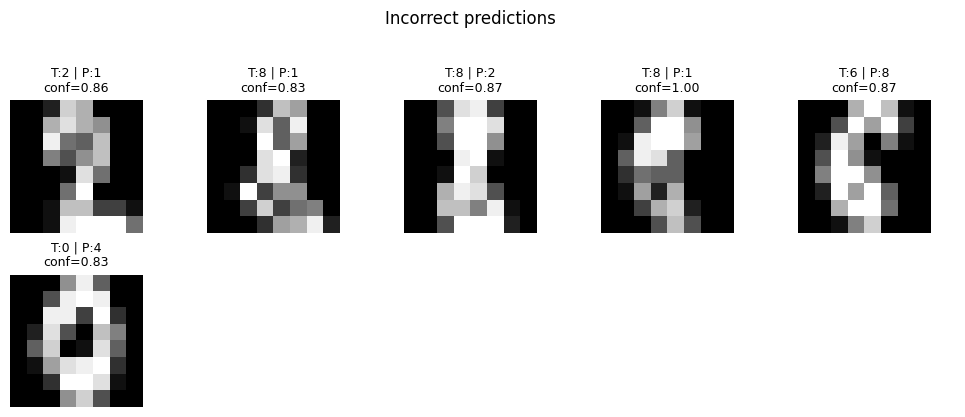

Figure saved to: C:\Users\Peter\ai-imaging-portfolio\06_explainability_and_evaluation\figures\01_incorrect_predictions.png


In [44]:
# ------------------------------------------------------------
# 26 · Visualize incorrect predictions
# ------------------------------------------------------------

error_indices = np.where(y_true != y_pred)[0]

n_errors_to_show = min(10, len(error_indices))

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
axes = axes.flat

for ax_idx, sample_idx in enumerate(error_indices[:n_errors_to_show]):
    ax = axes[ax_idx]

    image = X_test[sample_idx].reshape(8, 8)
    true_label = y_true[sample_idx]
    pred_label = y_pred[sample_idx]
    conf = confidence[sample_idx]

    ax.imshow(image, cmap="gray")
    ax.set_title(
        f"T:{true_label} | P:{pred_label}\nconf={conf:.2f}",
        fontsize=9
    )
    ax.axis("off")

for ax in axes[n_errors_to_show:]:
    ax.axis("off")

plt.suptitle("Incorrect predictions", y=1.03)
plt.tight_layout()

out = FIGURES_DIR / "01_incorrect_predictions.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {out}")

In [45]:
# ------------------------------------------------------------
# 27 · Most confident predictions
# ------------------------------------------------------------

most_confident = evaluation_df.sort_values("confidence", ascending=False).head(10)

most_confident

,true_label,predicted_label,confidence,correct
243,4,4,1.0,True
25,2,2,1.0,True
49,4,4,1.0,True
216,0,0,1.0,True
102,4,4,1.0,True
71,0,0,1.0,True
166,0,0,1.0,True
184,4,4,1.0,True
192,3,3,1.0,True
66,7,7,1.0,True


In [46]:
# ------------------------------------------------------------
# 28 · Least confident predictions
# ------------------------------------------------------------

least_confident = evaluation_df.sort_values("confidence", ascending=True).head(10)

least_confident

,true_label,predicted_label,confidence,correct
11,9,9,0.460898,True
179,9,9,0.482090,True
138,1,1,0.598578,True
257,1,1,0.703645,True
8,9,9,0.711482,True
110,9,9,0.742679,True
199,8,8,0.791122,True
197,7,7,0.813310,True
96,8,1,0.825797,False
218,0,4,0.833121,False


In [47]:
"""
## 12. Confianza del modelo

La confianza del modelo corresponde a la probabilidad máxima asignada por "softmax".

Una predicción correcta con alta confianza suele ser deseable.

Pero una predicción incorrecta con alta confianza es más preocupante, porque indica que el modelo está seguro de un error.

En aplicaciones científicas, estos casos requieren inspección manual porque pueden estar asociados a:

- muestras ambiguas,
- etiquetas incorrectas,
- artefactos,
- clases visualmente similares,
- extrapolación fuera del dominio de entrenamiento.
"""

'\n## 12. Confianza del modelo\n\nLa confianza del modelo corresponde a la probabilidad máxima asignada por "softmax".\n\nUna predicción correcta con alta confianza suele ser deseable.\n\nPero una predicción incorrecta con alta confianza es más preocupante, porque indica que el modelo está seguro de un error.\n\nEn aplicaciones científicas, estos casos requieren inspección manual porque pueden estar asociados a:\n\n- muestras ambiguas,\n- etiquetas incorrectas,\n- artefactos,\n- clases visualmente similares,\n- extrapolación fuera del dominio de entrenamiento.\n'

In [48]:
# ------------------------------------------------------------
# 29 · Save model
# ------------------------------------------------------------

model_path = MODELS_DIR / "01_evaluation_baseline_mlp.pt"

torch.save(model.state_dict(), model_path)

print(f"Model saved to: {model_path}")

Model saved to: C:\Users\Peter\ai-imaging-portfolio\06_explainability_and_evaluation\models\01_evaluation_baseline_mlp.pt
